In [74]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [14]:
df_customers = pd.read_csv("../data/olist_customers_dataset.csv")
df_geolocation = pd.read_csv("../data/olist_geolocation_dataset.csv")
df_order_items = pd.read_csv("../data/olist_order_items_dataset.csv")
df_payments = pd.read_csv("../data/olist_order_payments_dataset.csv")
df_reviews_dataset = pd.read_csv("../data/olist_order_reviews_dataset.csv")
df_orders = pd.read_csv("../data/olist_orders_dataset.csv")
df_products = pd.read_csv("../data/olist_products_dataset.csv")
df_sellers = pd.read_csv("../data/olist_sellers_dataset.csv")
df_product_category_name = pd.read_csv("../data/product_category_name_translation.csv")


Qual o faturamento total e médio por pedido?

In [4]:
faturamento_total = df_payments["payment_value"].sum()

print(f"O faturamento total foi {faturamento_total:.2f}")

df_payments["payment_value"].mean()

O faturamento total foi 16008872.12


np.float64(154.10038041699556)

Faturamento por pedido

In [5]:
df_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [6]:
df_payments["payment_value"].describe()

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

In [11]:
total_por_pedido = (df_payments.groupby(by=["order_id"], as_index=False)[["payment_value"]].sum()).sort_values("payment_value",ascending=False)
total_por_pedido

,order_id,payment_value
1471,03caa2c082116e1d31e67e9ae3700499,13664.08
44830,736e1922ae60d0d6a89247b851902527,7274.88
3156,0812eb902a67711a1cb742b3cdaa65ae,6929.31
99071,fefacc66af859508bf1a7934eab1e97f,6922.21
95186,f5136e38d1a14a4dbd87dff67da82701,6726.66
...,...,...
90468,e8bbc1d69fee39eee4c72cb5c969e39d,10.07
93949,f1d5c2e6867fa93ceee9ef9b34a53cbf,9.59
78007,c8c528189310eaa44a745b8d9d26908b,0.00
27282,4637ca194b6387e2d538dc89b124b0ee,0.00


In [25]:
df_payments

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


In [32]:
summary = (df_payments.groupby(by=["payment_type"], as_index=False).agg({"payment_value": ["sum", "mean"],
                                                                     "order_id":["count"]}))
summary.columns = ['payment_type', 'count', 'sum', 'mean']

summary.sort_values(by=["sum"], ascending=False)



,payment_type,count,sum,mean
1,credit_card,12542084.19,163.319021,76795
0,boleto,2869361.27,145.034435,19784
2,debit_card,217989.79,142.570170,1529
4,voucher,379436.87,65.703354,5775
3,not_defined,0.00,0.000000,3


In [33]:
df_payments.groupby('order_id')['payment_value'].sum().mean()

np.float64(160.9902666934835)

In [35]:
df_payments['order_id'].value_counts()

order_id
fa65dad1b0e818e3ccc5cb0e39231352    29
ccf804e764ed5650cd8759557269dc13    26
285c2e15bebd4ac83635ccc563dc71f4    22
895ab968e7bb0d5659d16cd74cd1650c    21
ee9ca989fc93ba09a6eddc250ce01742    19
                                    ..
0406037ad97740d563a178ecc7a2075c     1
7b905861d7c825891d6347454ea7863f     1
32609bbb3dd69b3c066a6860554a77bf     1
b8b61059626efa996a60be9bb9320e10     1
28bbae6599b09d39ca406b747b6632b1     1
Name: count, Length: 99440, dtype: int64

In [41]:
summary = df_payments.groupby('order_id', as_index=False).agg(
    total=('payment_value', 'sum'),
    media=('payment_value', 'mean'),
    count=('order_id', 'count')
)

summary.sort_values('count', ascending=False)

,order_id,total,media,count
97261,fa65dad1b0e818e3ccc5cb0e39231352,457.99,15.792759,29
79611,ccf804e764ed5650cd8759557269dc13,62.68,2.410769,26
15577,285c2e15bebd4ac83635ccc563dc71f4,40.85,1.856818,22
53168,895ab968e7bb0d5659d16cd74cd1650c,161.32,7.681905,21
99020,fedcd9f7ccdc8cba3a18defedd1a5547,205.74,10.828421,19
...,...,...,...,...
99419,fff1e3e76b816bfe8ef16678cc53c643,86.85,86.850000,1
99420,fff2cdc825f9fc0ba3c04227cfa02303,50.62,50.620000,1
99421,fff2e9e3aa8644e19710216b4ef53ab2,86.15,86.150000,1
99422,fff3983dfa3c5a0d752d8d17baa406a0,80.44,80.440000,1


In [48]:
summary = (df_payments.groupby(by=["order_id"], as_index=False).agg({"payment_value": ["sum", "mean"],
                                                                     "payment_sequential":["count"]}))

summary.columns = ['order_id', 'sum', 'mean', 'count']

summary.sort_values('count', ascending=False)

,order_id,sum,mean,count
97261,fa65dad1b0e818e3ccc5cb0e39231352,457.99,15.792759,29
79611,ccf804e764ed5650cd8759557269dc13,62.68,2.410769,26
15577,285c2e15bebd4ac83635ccc563dc71f4,40.85,1.856818,22
53168,895ab968e7bb0d5659d16cd74cd1650c,161.32,7.681905,21
99020,fedcd9f7ccdc8cba3a18defedd1a5547,205.74,10.828421,19
...,...,...,...,...
99419,fff1e3e76b816bfe8ef16678cc53c643,86.85,86.850000,1
99420,fff2cdc825f9fc0ba3c04227cfa02303,50.62,50.620000,1
99421,fff2e9e3aa8644e19710216b4ef53ab2,86.15,86.150000,1
99422,fff3983dfa3c5a0d752d8d17baa406a0,80.44,80.440000,1


2.1) Quais categorias de produto geram mais receita?

In [51]:
df_order_items.head(5)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [52]:
df_products.head(5)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [69]:
df_join = df_order_items.merge(
    df_products,
    on=["product_id"],
    how='left'
).groupby(by=["product_category_name"], as_index=False)[["price"]].sum()

df_join.columns = ['categoria', 'price']

top_10_categorias = df_join.sort_values("price", ascending=False).head(10)

In [80]:
top_10_categorias.dtypes


categoria        str
price        float64
dtype: object

C:\Users\brito\AppData\Local\Temp\ipykernel_24052\1554326225.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


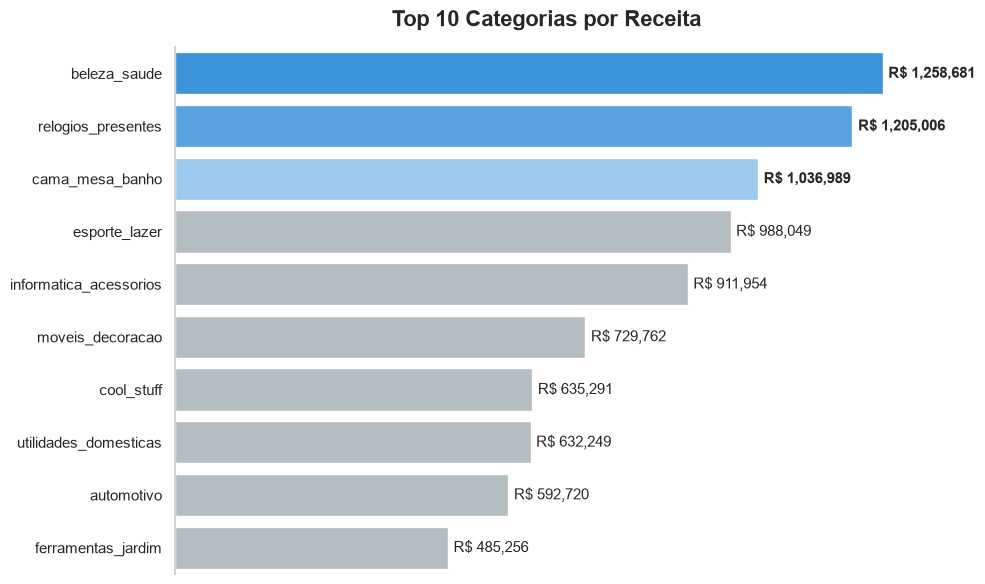

In [86]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

colors = ["#2196F3", "#42A5F5", "#90CAF9"] + ["#B0BEC5"] * 7

sns.barplot(
    data=top_10_categorias,
    y="categoria",
    x="price",
    palette=colors,
    orient='h',
    ax=ax
)

ax.set_title('Top 10 Categorias por Receita', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('')
ax.xaxis.set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

for index, value in enumerate(top_10_categorias['price']):
    weight = 'bold' if index < 3 else 'normal'
    ax.text(value + 10000, index, f'R$ {value:,.0f}', va='center', fontsize=11, fontweight=weight)

plt.tight_layout()
plt.show()

Como as vendas evoluíram ao longo do tempo?
